In [36]:
import qil_helpers.Ben.General as Ben
import matplotlib.pyplot as plt
import numpy as np
import qil_SpinHamiltonian.spin_hamiltonian as spin
import yaml
import matplotlib.colors as clr
import plotly.graph_objects as go
import scipy as sp
from matplotlib import colors

In [37]:
B1=np.load('./saved/site_1_2.npy')
#B1=np.load('./saved/site_1_GN.npy')

B2=np.load('./saved/site_2_2.npy')

# fig=go.Figure(data=[go.Scatter3d(x=B1[0,:],y=B1[1,:],z=B1[2,:]),
#                     go.Scatter3d(x=B2[0,:],y=B2[1,:],z=B2[2,:])
#                     ])
# fig.show()

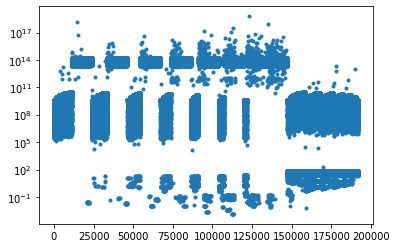

In [50]:
R1=np.abs(np.linalg.norm(B1,axis=0))
R2=np.abs(np.linalg.norm(B2,axis=0))

RT=1E1

idx1=np.where(R1<RT)[0]
idx2=np.where(R2<RT)[0]
k=B1.shape[1]//120


tidx1=idx1//k
tidx2=idx2//k

BT1=B1[:,idx1]
BT2=B2[:,idx2]

plt.plot(R1,'.')
plt.yscale('log')

In [39]:

def takeBlock(A):
    i,a,n=A.shape
    k=n//a
    B=A.reshape(3,a,a,k)
    B=B[:,np.arange(a),np.arange(a)].reshape(3,n)
    return B

In [44]:
path="C:/Users/neb16/Documents/Uni/PHD/Experiments/Simulations/Spin_Hamiltonian/spin_hamiltonian/ion_params/"
#gnd=
#gnd="Er_YSO_site1_ground_chen.yml"

Site1=spin.hamilFromYAML(path+"Er_YSO_site1_ground_wang.yml")
#Site1=spin.hamilFromYAML(path+"Er_YSO_site1_ground_GN.yml")

Site2=spin.hamilFromYAML(path+"Er_YSO_site2_ground_wang.yml")

i,j=np.triu_indices(Site1.dim,k=1)

FG1,VG1=Site1.getEigFreq(BT1)
FG2,VG2=Site2.getEigFreq(BT2)

SG1=Site1.gradient(VG1)
SG2=Site2.gradient(VG2)

SC1=Site1.curvature(VG1,FG1)
SC2=Site2.curvature(VG2,FG2)


#ST1=np.diagonal(SG1[:,i[tidx1],:]-SG1[:,j[tidx1],:],axis1=0,axis2=1)
#ST2=np.diagonal(SG2[:,i[tidx2],:]-SG2[:,j[tidx2],:],axis1=0,axis2=1)
ST1=(SG1[:,i,:]-SG1[:,j,:])[np.arange(tidx1.shape[0]),tidx1,:]
ST2=SG2[:,i,:]-SG2[:,j,:]


#CT1=np.diagonal(SC1[:,i[tidx1],...]-SC1[:,j[tidx1],...],axis1=0,axis2=1)
#CT2=np.diagonal(SC1[:,i[tidx1],...]-SC1[:,j[tidx1],...],axis1=0,axis2=1)

CT1=(SC1[:,i,...]-SC1[:,j,...])[np.arange(tidx1.shape[0]),tidx1,...]
CT2=SC2[:,i,...]-SC2[:,j,...]

TT1=FG1[:,i]-FG1[:,j]
TT2=FG2[:,i]-FG2[:,j]


# TT1=np.diag(FG1[:,i[tidx1]]-FG1[:,j[tidx1]])
# TT2=np.diag(FG2[:,i[tidx2]]-FG2[:,j[tidx2]])




{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Rotation': {'rot': 'ZXZ'}, 'E_Zeeman': {'g': 'np.diag([2.16,-0.1,14.7])', 'g_rot': 'np.array([205.2,55.3,30])*np.pi/180'}, 'N_Zeeman': {'mu': '-0.56'}, 'Hyperfine': {'A': 'np.diag([191.1,-36,1544])*1e6*h', 'A_rot': 'np.array([202,51.8,-6])*np.pi/180'}, 'Quadrupole': {'Q': 'np.diag([9.6,18.3,-27.9])*1e6*h', 'Q_rot': 'np.array([147,50,316])*np.pi/180'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}
{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Rotation': {'rot': 'ZXZ'}, 'E_Zeeman': {'g': 'np.diag([1.0,1.7,15.1])', 'g_rot': 'np.array([262.2,100,101])*np.pi/180'}, 'N_Zeeman': {'mu': '-0.56'}, 'Hyperfine': {'A': 'np.diag([158.1,7,-1611])*1e6*h', 'A_rot': 'np.array([262,94,77])*np.pi/

C:\Users\neb16\AppData\Roaming\Python\Python39\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


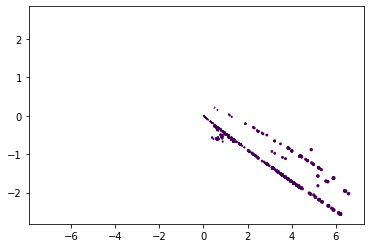

In [46]:
N=np.abs(np.linalg.norm(CT1,2,axis=(1,2)))

plt.scatter(BT1[0,:],BT1[1,:],BT1[2,:],c=N)


In [ ]:
raise ValueError

ValueError: 

Site 1: 1.3484375
Site 2: 2.021875


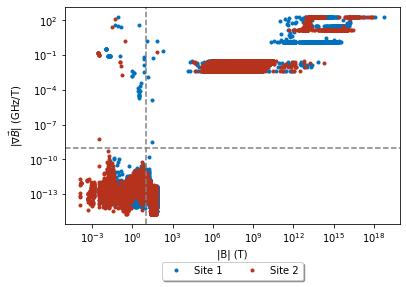

In [ ]:
ST1a=takeBlock(ST1.T).T
#aSG1=np.einsum('ij,ij->i',ST1a,ST1a)
aSG1=np.linalg.norm(ST1a,axis=1)#np.einsum('ij,ij->j',SG1,SG1)

ST2a=takeBlock(ST2.T).T
aSG2=np.linalg.norm(ST2a,axis=1)#np.einsum('ij,ij->j',SG1,SG1)
#aSG2=np.einsum('ij,ij->i',ST2a,ST2a)



RT=1E1
GT=1E-9





plt.plot(R1,aSG1,'.',color=Ben.ROYALBLUE,label='Site 1')
plt.plot(R2,aSG2,'.',color=Ben.BRICKRED,label='Site 2')

plt.axhline(GT,color='gray',linestyle='dashed')
plt.axvline(RT,color='gray',linestyle='dashed')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('|B| (T)' )
plt.ylabel(r'|$\nabla\vec{B}$| (GHz/T)' )
Ben.goodLegend()

idx1=np.where(np.logical_and(R1<RT,aSG1<GT))[0]
idx2=np.where(np.logical_and(R2<RT,aSG2<GT))[0]



print("Site 1: %s"%(100*len(idx1)/B1.shape[1]))
print("Site 2: %s"%(100*len(idx2)/B2.shape[1]))

Ben.goodFigSave("./images/",'Found_points.pgf',final=True)
Ben.goodFigSave("./images/",'Found_points.pdf',final=True)

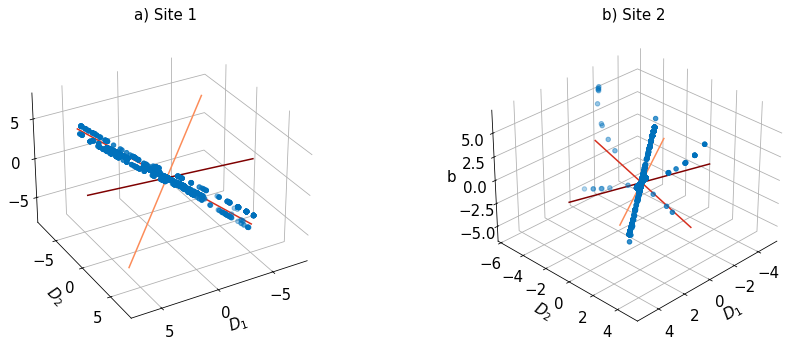

In [ ]:
Ben.pltPubParams(fs=15,figscale=1.2)
fig=plt.figure(figsize=(6.4*1.2*2,4.8*1.2))
a1=fig.add_subplot(1,2,1,projection='3d',)

RT1=Site1.RE
RT2=Site2.RE


C1=RT1@np.eye(3)
C2=RT2@np.eye(3)

a1.scatter(B1[0,idx1],B1[1,idx1],B1[2,idx1],c=Ben.ROYALBLUE)
#a1.scatter(B1[0,idx1],B1[1,idx1],B1[2,idx1],c=np.abs(TT1[idx1,idx1//k]))

# a1.scatter(B1[0,idx1],B1[2,idx1],-10,zdir='y',c=Ben.BRICKRED,alpha=0.1)
# a1.scatter(B1[1,idx1],B1[2,idx1],-10,zdir='x',c=Ben.BRICKRED,alpha=0.1)
# a1.scatter(B1[0,idx1],B1[1,idx1],-10,zdir='z',c=Ben.BRICKRED,alpha=0.1)


a1.set_xlabel('$D_1$')
a1.set_ylabel('$D_2$')
a1.set_zlabel('b')
a1.view_init(30,90-30)
#a1.view_init(0,0)
a1.set_title('a) Site 1')

print()
off=10

a2=fig.add_subplot(1,2,2,projection='3d',)

a2.scatter(B2[0,idx2],B2[1,idx2],B2[2,idx2],c=Ben.ROYALBLUE)

# a2.scatter(B2[0,idx2],B2[2,idx2],-5,zdir='y',c=Ben.GOLDENROD,alpha=0.1)
# a2.scatter(B2[1,idx2],B2[2,idx2],-5,zdir='x',c=Ben.GOLDENROD,alpha=0.1)
# a2.scatter(B2[0,idx2],B2[1,idx2],-5,zdir='z',c=Ben.GOLDENROD,alpha=0.1)


a2.set_xlabel('$D_1$')
a2.set_ylabel('$D_2$')
a2.set_zlabel('b')
a2.view_init(30,45)
#a2.view_init(0,0)

a2.set_title('b) Site 2')

off1=10*np.array([1,1,1])
off2=5*np.array([1,1,1])

#Ben.goodColourmap(plt.cm.OrRd,3,)
cm=plt.cm.OrRd(np.linspace(0.5,1,3))
for i in range (3):
#    print(C1[i,:])
    co1=np.hstack([-off1[i]*C1[:,i],off1[i]*C1[:,i]])
    co2=np.hstack([-off2[i]*C2[:,i],off2[i]*C2[:,i]])

    a1.plot3D(*co1,color=cm[i])
    a2.plot3D(*co2,color=cm[i])


a1.xaxis.pane.fill = False
a1.yaxis.pane.fill = False
a1.zaxis.pane.fill = False
a1.xaxis.pane.set_edgecolor('w')
a1.yaxis.pane.set_edgecolor('w')
a1.zaxis.pane.set_edgecolor('w')

a2.xaxis.pane.fill = False
a2.yaxis.pane.fill = False
a2.zaxis.pane.fill = False
a2.xaxis.pane.set_edgecolor('w')
a2.yaxis.pane.set_edgecolor('w')
a2.zaxis.pane.set_edgecolor('w')
Ben.goodFigSave("./images/",'ZEFOZ.pgf',final=True)
Ben.goodFigSave('./images/','ZEFOZ.pdf',final=True)


In [ ]:
def Spherical(B):
        R=np.linalg.norm(B,axis=0)
        theta=np.acos(B[2,:]/R)
        phi=np.sign(B[1,:])*np.acos(B[0,:]/np.sqrt(np.square(B[0,:])+np.square(B[1,:])))
        return R,theta,phi


def plotlCoords(CH1,off=1,**kwargs):
        coords=[go.Scatter3d( x = [-off*CH1[0,i],off*CH1[0,i]],
                       y = [-off*CH1[1,i],off*CH1[1,i]],
                       z = [-off*CH1[2,i],off*CH1[2,i]],
                       line = dict( color = "rgb(0,0,0)",
                                    width = 6,**kwargs),
                        text=l,
                        mode='lines'
                     ) for i,l in enumerate(range(3))]
        return coords

[[ 0.78887331  0.61451465 -0.00711751]
 [-0.61235701  0.78697687  0.07540755]
 [ 0.05194035 -0.05512855  0.9971274 ]]


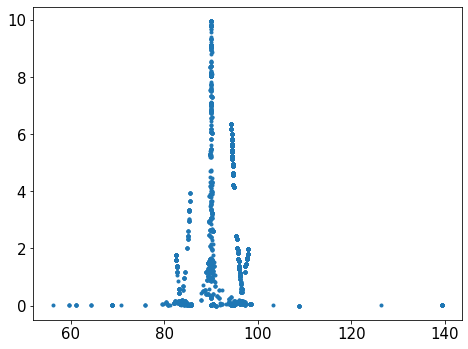

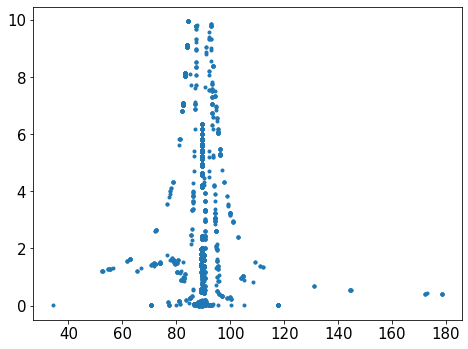

In [ ]:
B1R=np.array(RT1.T@B1[:,idx1])
#B1R=np.array(np.eye(3)@B1[:,idx1])
CH1=RT1.T@(Site1.RH@np.eye(3))
print(CH1)
#print(RT1.T@C1)
coordsH=plotlCoords(CH1,dash='dash',off=1)
coordsQ=plotlCoords(RT1.T@(Site1.RQ@np.eye(3)),off=1)
fig=go.Figure(data=[go.Scatter3d(x=B1R[0,:],y=B1R[1,:],z=B1R[2,:]
        ,mode='markers',
        marker=dict(
        size=2,
        opacity=0.5
        )),*coordsH,*coordsQ])
fig.show()

R1R,T1R,P1R=Spherical(B1R)#np.linalg.norm(B1R,axis=0)
#fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
plt.plot(T1R*180/np.pi,R1R,'.')
plt.show()
#fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
plt.plot(np.abs(P1R)*180/np.pi,R1R,'.')
plt.show()


[[ 1.00000000e+00  1.72521339e-17  1.46641661e-16]
 [ 1.72521339e-17  1.00000000e+00 -2.24876042e-17]
 [ 1.46641661e-16 -2.24876042e-17  1.00000000e+00]]


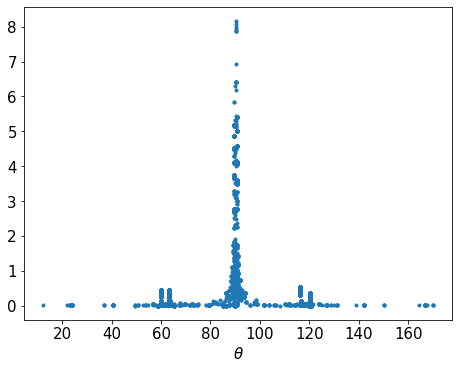

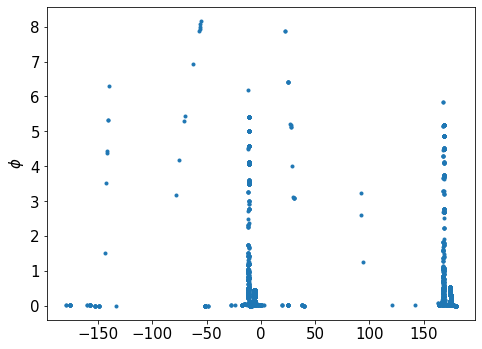

In [ ]:

B2R=np.array(RT2.T@B2[:,idx2])
print(RT2.T@C2)
coordsH=plotlCoords(RT2@(Site2.RH@np.eye(3)),dash='dash')
coordsQ=plotlCoords(RT2@(Site2.RQ@np.eye(3)))

fig=go.Figure(data=[go.Scatter3d(x=B2R[0,:],y=B2R[1,:],z=B2R[2,:]
        ,mode='markers',
        marker=dict(
        size=2,
        opacity=0.5
        )),*coordsH,*coordsQ])
fig.show()
R2R,T2R,P2R=Spherical(B2R)#np.linalg.norm(B1R,axis=0)
#fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
plt.plot(T2R*180/np.pi,R2R,'.')
plt.xlabel(r'$\theta$')
plt.show()
#fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
plt.plot(P2R*180/np.pi,R2R,'.')
plt.ylabel(r'$\phi$')

plt.show()


[[ 0.44854916 -0.7656164   0.46112382]
 [ 0.60446206  0.6399129   0.47448614]
 [-0.65835346  0.06590149  0.74981846]]
0.6044620566146078 0.6399129010955149


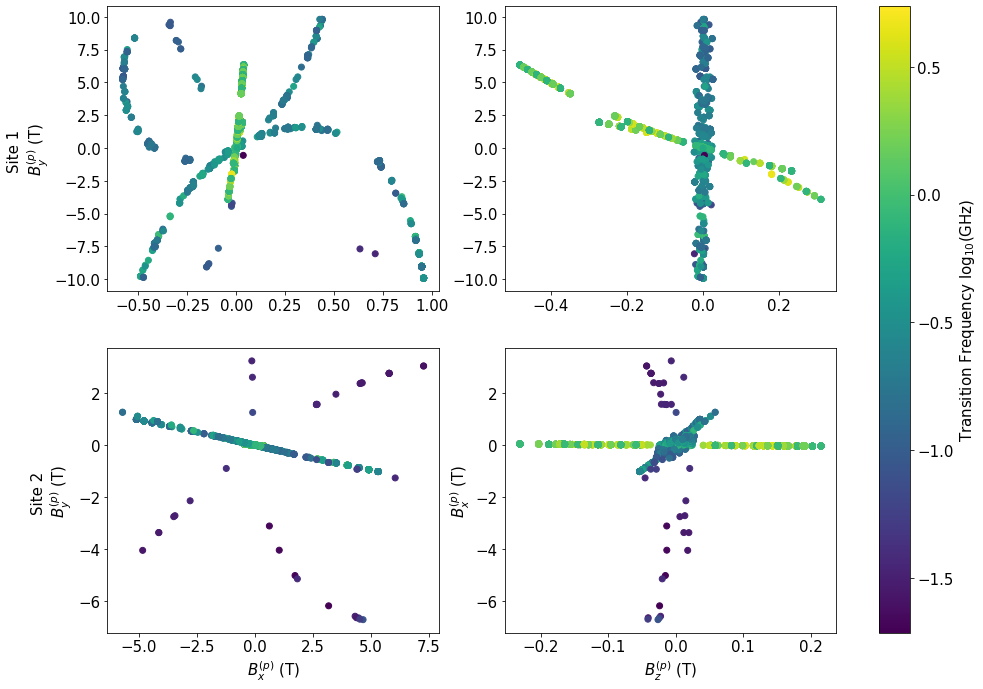

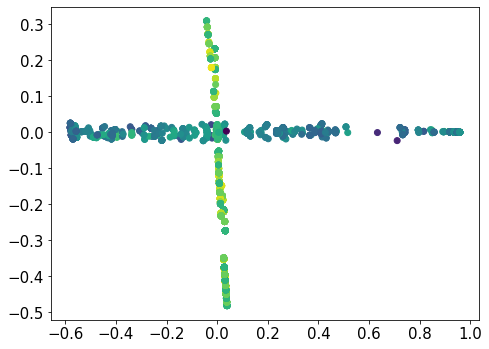

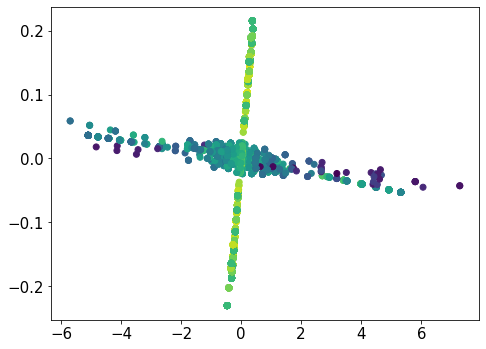

In [ ]:
CH1=RT1.T@(Site1.RQ@np.eye(3))
CH1=RT1@Site1.RH@np.eye(3)#RT1.T@(Site1.RQ@np.eye(3))
CH1=CH1/np.linalg.norm(CH1,axis=1)


print(CH1)

#cm=plt.cm.viridis(np.linspace(0,1,120))


cm='viridis'

#plt.plot(idx1,idx1//k)

print(CH1[1,0],CH1[1,1])

BTT1=np.log10(np.abs(TT1[idx1,idx1//k]))#takeBlock(TT1.T).T
BTT2=np.log10(np.abs(TT2[idx2,idx2//k]))
#BTT1=(np.abs(TT1[idx1,idx1//k]))#takeBlock(TT1.T).T
#BTT2=(np.abs(TT2[idx2,idx2//k]))

#BTT1=idx1//k#np.log10(np.abs(TT1[idx1,idx1//k]))#takeBlock(TT1.T).T
#BTT2=idx2//k#np.log10(np.abs(TT2[idx2,idx2//k]))


#fig=plt.figure()
fig,axs=plt.subplots(2,2,figsize=(6.4*1.2*2,4.8*1.2*2))

a1,a2,a3,a4=axs.flatten()
#a1=fig.subplot(2,2,1)
#BTT1=
pl1=a1.scatter(B1R[0,:],B1R[1,:],c=BTT1,cmap=cm)
a2.scatter(B1R[2,:],B1R[1,:],c=BTT1,cmap=cm)

a3.scatter(B2R[0,:],B2R[1,:],c=BTT2,cmap=cm)

a4.scatter(B2R[2,:],B2R[1,:],c=BTT2,cmap=cm)

#plt.plot(np.array([0,CH1[1,1]]),np.array([0,CH1[2,2]]),'k.--')
#plt.plot(np.array([0,CH1[1,0]])*20,np.array([0,CH1[1,1]])*20,'k--')

#plt.plot(-20*CH1[1,:],20*CH1[1,:],'k--')

a1.set_ylabel("Site 1 \n"+ r"$B^{(p)}_{y} $ (T)")
a3.set_ylabel("Site 2 \n"+r"$B^{(p)}_{y} $ (T)")

a3.set_xlabel(r"$B^{(p)}_{x} $ (T)")
a4.set_xlabel(r"$B^{(p)}_{z}$ (T)")
a4.set_ylabel(r"$B^{(p)}_{x}$ (T)")
a4.yaxis.set_label_coords(-0.1,0.5)


#plt.ylabel(r"$B^{(p)}_{z}$ (T)")
fig.colorbar(pl1,ax=axs,cmap='viridis',fraction=0.1, label=r"Transition Frequency log$_{10}$(GHz)" )
#.add_colorbar()
#plt.plot()
#Ben.goodFigSave("./images/",'ZEFOZ_P.pgf',final=True)
#Ben.goodFigSave('./images/','ZEFOZ_P.pdf',final=True)

plt.show()

plt.scatter(B1R[0,:],B1R[2,:],c=BTT1,cmap=cm)
plt.show()
plt.scatter(B2R[0,:],B2R[2,:],c=BTT2,cmap=cm)
plt.show()

#plt.scatter(B2R[0,:],B2R[1,:],c=idx2//k,cmap='viridis',fraction=0.1)


396 20
484 22


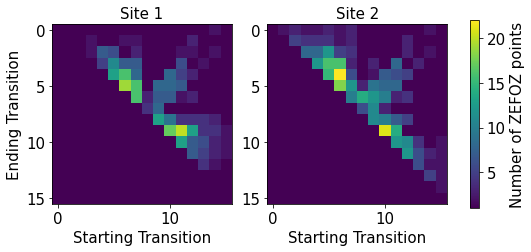

In [ ]:
Bu1,Bu1i=np.unique(np.round(B1[:,idx1],6),axis=1,return_index=True)
Bu2,Bu2i=np.unique(np.round(B2[:,idx2],6),axis=1,return_index=True)

#B1,Bu1i=np.unique(np.round(B1,3),axis=1,return_index=True)
#B2,Bu2i=np.unique(np.round(B2,3),axis=1,return_index=True)

k=B1.shape[1]//120
i,j=np.triu_indices(Site1.dim,k=1)
U1,C1=np.unique(idx1[Bu1i]//k,return_counts=True)
U2,C2=np.unique(idx2[Bu2i]//k,return_counts=True)


#print("%s: %s<->%s"%(tMax,i[tMax],j[tMax]))

Matdist1=np.zeros((Site1.dim,Site1.dim))
Matdist1[i[U1],j[U1]]=C1
#Matdist1[i[U1],j[U1]]=BTT1[Bu1i]

fig,axs=plt.subplots(1,2,figsize=(6.4*1.3*1,4.8*1.2*2))
Matdist2=np.zeros((Site2.dim,Site2.dim))
Matdist2[i[U2],j[U2]]=C2
#Matdist2[i[U2],j[U2]]=BTT2[Bu2i]

print(np.sum(C1),np.max(C1))
print(np.sum(C2),np.max(C2))

a1,a2=axs.flatten()

a1.set_xlabel("Starting Transition")
a1.set_ylabel("Ending Transition")
a2.set_xlabel("Starting Transition")
a1.set_title("Site 1")
a2.set_title("Site 2")

norm=colors.Normalize(vmin=np.min([np.min(C1),np.min(C2)]), vmax=np.max([np.max(C1),np.max(C2)]))
pl1=a1.imshow(Matdist1,norm=norm)
a2.imshow(Matdist2,norm=norm)
fig.colorbar(pl1,ax=axs,cmap='viridis',fraction=0.1, label=r"Number of ZEFOZ points", shrink=0.3)
Ben.goodFigSave("./images/",'ZEFOZ_Trans.pgf',final=True)
Ben.goodFigSave('./images/','ZEFOZ_Trans.pdf',final=True)

plt.show()


In [ ]:
import matplotlib.patches as patches
from matplotlib.offsetbox import DrawingArea, AnnotationBbox
#from matplotlib.patches import Ellipse

def ellpatch(ax,cx,cy,w,h,**kwargs):
    da = DrawingArea(w, h)

    defKwargs={"angle":0,      # Angle of rotation in degrees
    "facecolor":'none',
    "edgecolor":Ben.BRICKRED,
    "alpha":0.7,
    "linewidth":3}
    kwargs={**defKwargs,**kwargs}
    bbox = ax.get_window_extent()
    ellipse = patches.Ellipse(
    (w//2, h//2),        # Center (xy)
    w*bbox.width,             # Width
    h*bbox.width,             # Height
    **kwargs
    )
    da.add_artist(ellipse)
    ab = AnnotationBbox(
    da,
    (cx, cy),        # center in data coords
    xycoords='data',
    frameon=False
)
    ax.add_artist(ab)
    return ellipse


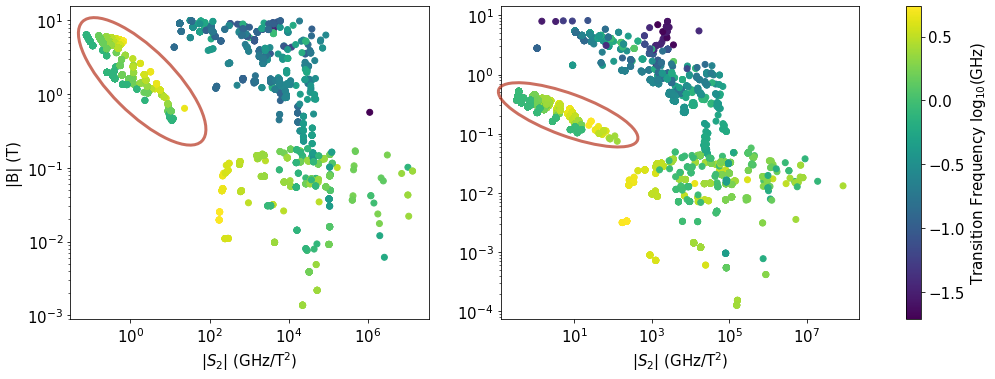

In [ ]:
#SCT1=SC1[idx1,i[idx1//k],...]-SC1[idx1,j[idx1//k],...]
SCT2=SC2[idx2,i[idx2//k],...]-SC2[idx2,j[idx2//k],...]
SCT1=CT1[idx1,idx1//k]
#SCT=CT1[idx1,idx1//k]

#SCT2=SC2[idx2,i,:]-SC2[idx2,j,:]
#norm=colors.Normalize(vmin=np.min([np.min(BTT1R),np.min(BTT2R)]), vmax=np.max([np.max(BTT1R),np.max(BTT2R)]))
fig,axs=plt.subplots(1,2,figsize=(6.4*1.3*2,4.8*1.2*1))
a1,a2=axs.flatten()

#plt.plot(R1R,np.linalg.norm(S21,2,axis=(1,2)),'.')
#plt.plot(,R1R,'.')
pl1=a1.scatter(np.linalg.norm(SCT1,2,axis=(1,2)),np.linalg.norm(B1[:,idx1],axis=0),c=BTT1)#,norm=norm
a1.set_yscale('log')
a1.set_xscale('log')
a1.set_ylabel("|B| (T)")
a1.set_xlabel(r"$|S_2|$ (GHz/T$^{2}$)")

oval_patch=ellpatch(a1,2,1.5,0.15,0.4,angle=45,zorder=-1)
#a1.add_patch(oval_patch)

# a2.scatter(np.linalg.norm(S22,2,axis=(1,2)),R2R,c=BTT2R,norm=norm)
a2.scatter(np.linalg.norm(SCT2,2,axis=(1,2)),np.linalg.norm(B2[:,idx2],axis=0),c=BTT2)
a2.set_yscale('log')
a2.set_xscale('log')
#a2.ylabel("|B| (T)")
a2.set_xlabel(r"$|S_2|$ (GHz/T$^{2}$)")


oval_patch=ellpatch(a2,7,0.21,0.1,0.35,angle=70,zorder=-1)

fig.colorbar(pl1,ax=axs,cmap='viridis',fraction=0.1, label=r"Transition Frequency log$_{10}$(GHz)", shrink=1)
#Ben.goodFigSave("./images/",'Curvature.pdf',final=True)
plt.show()


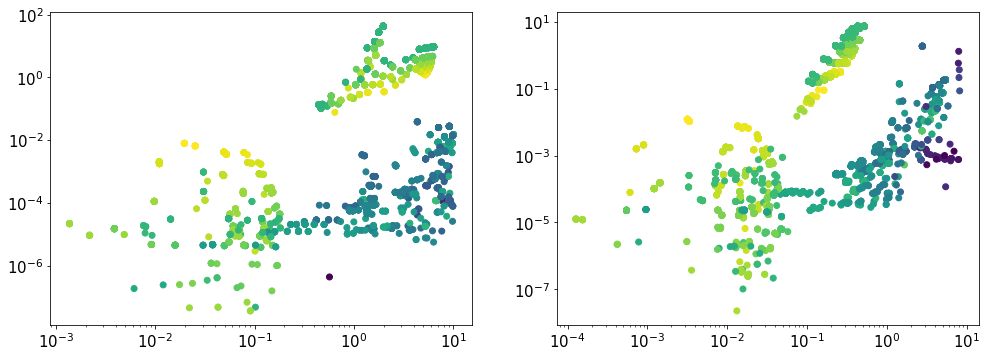

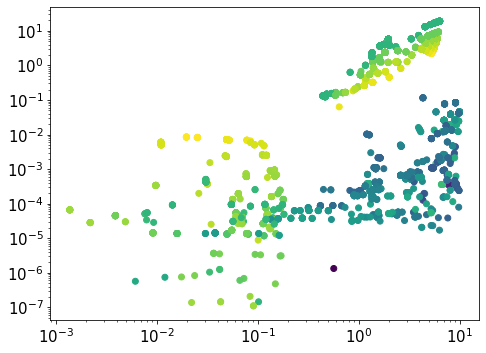

In [ ]:
dB=26E-6
Bvec=np.array([1,1,1],dtype=float).T
#Bvec=Bvec/np.linalg.norm(Bvec)

Bvec=np.squeeze(np.array(RT1.T@Bvec).T)
Bvec=Bvec/np.linalg.norm(Bvec)

Bvec*=dB

#T2i1=

T21G=Bvec.T@ST1a[idx1,:].T
T21C=Bvec.T@((SCT1)@Bvec).T

T22G=Bvec.T@ST2a[idx2,:].T
T22C=Bvec.T@((SCT2)@Bvec).T


T21=1E-9/np.abs(np.pi*(T21C+T21G))
T22=1E-9/np.abs(np.pi*(T22C+T22G))

#np.einsum('ijk')#Bvec.T@ST1a[idx1,:].T

#plt.plot()
#p
fig,axs=plt.subplots(1,2,figsize=(6.4*1.3*2,4.8*1.2*1))
a1,a2=axs.flatten()

C1m=np.linalg.norm(SCT1,2,axis=(1,2))*1E9

#plt.scatter(np.linalg.norm(B1[:,idx1],axis=0),1/(C1m*np.power(dB,2)),c=BTT1)
pl1=a1.scatter(np.linalg.norm(B1[:,idx1],axis=0),T21,c=BTT1)
a1.set_xscale('log')
a1.set_yscale('log')

a2.scatter(np.linalg.norm(B2[:,idx2],axis=0),T22,c=BTT2)
a2.set_xscale('log')
a2.set_yscale('log')


plt.show()
plt.scatter(np.linalg.norm(B1[:,idx1],axis=0),1/(C1m*np.power(dB,2)),c=BTT1)

plt.xscale('log')
plt.yscale('log')

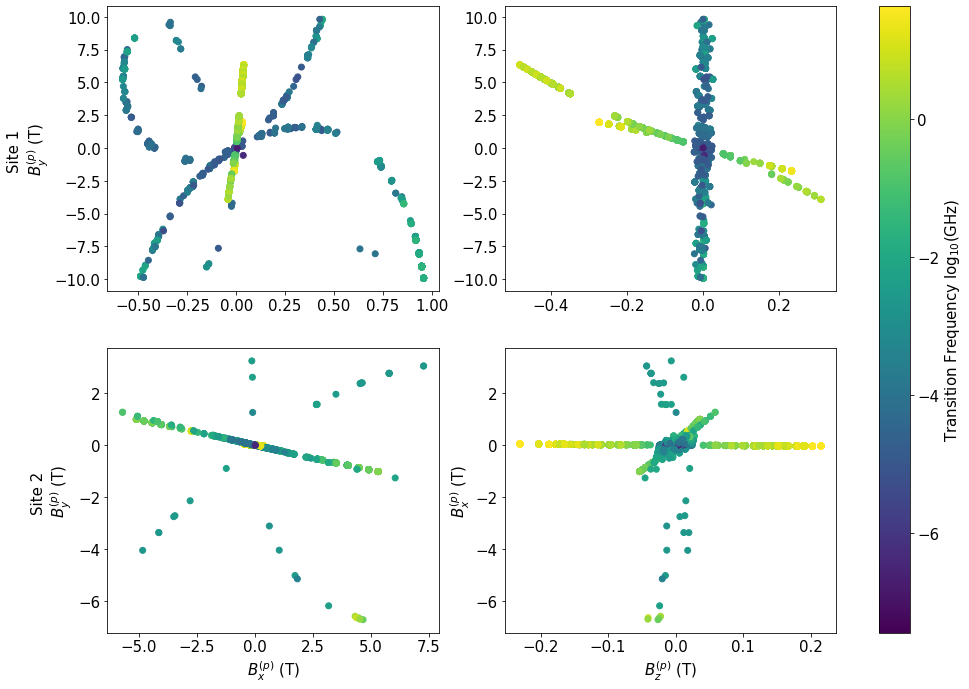

In [ ]:
fig,axs=plt.subplots(2,2,figsize=(6.4*1.2*2,4.8*1.2*2))

a1,a2,a3,a4=axs.flatten()
#a1=fig.subplot(2,2,1)
#BTT1=
pl1=a1.scatter(B1R[0,:],B1R[1,:],c=np.log10(T21),cmap=cm)
a2.scatter(B1R[2,:],B1R[1,:],c=np.log10(T21),cmap=cm)

a3.scatter(B2R[0,:],B2R[1,:],c=np.log10(T22),cmap=cm)

a4.scatter(B2R[2,:],B2R[1,:],c=np.log10(T22),cmap=cm)

#plt.plot(np.array([0,CH1[1,1]]),np.array([0,CH1[2,2]]),'k.--')
#plt.plot(np.array([0,CH1[1,0]])*20,np.array([0,CH1[1,1]])*20,'k--')

#plt.plot(-20*CH1[1,:],20*CH1[1,:],'k--')

a1.set_ylabel("Site 1 \n"+ r"$B^{(p)}_{y} $ (T)")
a3.set_ylabel("Site 2 \n"+r"$B^{(p)}_{y} $ (T)")

a3.set_xlabel(r"$B^{(p)}_{x} $ (T)")
a4.set_xlabel(r"$B^{(p)}_{z}$ (T)")
a4.set_ylabel(r"$B^{(p)}_{x}$ (T)")
a4.yaxis.set_label_coords(-0.1,0.5)


#plt.ylabel(r"$B^{(p)}_{z}$ (T)")
fig.colorbar(pl1,ax=axs,cmap='viridis',fraction=0.1, label=r"Transition Frequency log$_{10}$(GHz)" )
#.add_colorbar()
#plt.plot()
#Ben.goodFigSave("./images/",'ZEFOZ_P.pgf',final=True)
#Ben.goodFigSave('./images/','ZEFOZ_P.pdf',final=True)

plt.show()

In [ ]:
raise ValueError

ValueError: 

In [ ]:


idx1R=idx1[Bu1i]
B1R=B1[:,idx1R]

R1R=np.linalg.norm(B1R,axis=0)
FG1R,VG1R=Site1.getEigFreq(B1R)
S11R=Site1.gradient(VG1R)
S21R=Site1.curvature(VG1R,FG1R)

T1R=np.diag(FG1R[:,i[idx1R//k]]-FG1R[:,j[idx1R//k]])
S11=np.diagonal(S11R[:,i[idx1R//k],...]-S11R[:,j[idx1R//k],...],axis1=0,axis2=1).T
S21=np.diagonal(S21R[:,i[idx1R//k],...]-S21R[:,j[idx1R//k],...],axis1=0,axis2=1).T


idx2R=idx2[Bu2i]
B2R=B2[:,idx2R]

R2R=np.linalg.norm(B2R,axis=0)
FG2R,VG2R=Site2.getEigFreq(B2R)
S12R=Site2.gradient(VG2R)
S22R=Site2.curvature(VG2R,FG2R)

T2R=np.diag(FG2R[:,i[idx2R//k]]-FG2R[:,j[idx2R//k]])
S12=np.diagonal(S12R[:,i[idx2R//k],...]-S12R[:,j[idx2R//k],...],axis1=0,axis2=1).T
S22=np.diagonal(S22R[:,i[idx2R//k],...]-S22R[:,j[idx2R//k],...],axis1=0,axis2=1).T



fig,axs=plt.subplots(1,2,figsize=(6.4*1.3*2,4.8*1.2*1))
a1,a2=axs.flatten()


BTT1R=np.log(np.abs(T1R))
BTT2R=np.log(np.abs(T2R))

norm=colors.Normalize(vmin=np.min([np.min(BTT1R),np.min(BTT2R)]), vmax=np.max([np.max(BTT1R),np.max(BTT2R)]))

#plt.plot(R1R,np.linalg.norm(S21,2,axis=(1,2)),'.')
#plt.plot(,R1R,'.')
pl1=a1.scatter(np.linalg.norm(S21,2,axis=(1,2)),R1R,c=BTT1R,norm=norm)
a1.set_yscale('log')
a1.set_xscale('log')
a1.set_ylabel("|B| (T)")
a1.set_xlabel(r"$|S_2|$ (GHz/T$^{2}$)")

oval_patch=ellpatch(a1,2,1.5,0.15,0.4,angle=45,zorder=-1)
#a1.add_patch(oval_patch)

a2.scatter(np.linalg.norm(S22,2,axis=(1,2)),R2R,c=BTT2R,norm=norm)
a2.set_yscale('log')
a2.set_xscale('log')
#a2.ylabel("|B| (T)")
a2.set_xlabel(r"$|S_2|$ (GHz/T$^{2}$)")


oval_patch=ellpatch(a2,7,0.21,0.1,0.35,angle=70,zorder=-1)

fig.colorbar(pl1,ax=axs,cmap='viridis',fraction=0.1, label=r"Transition Frequency log$_{10}$(GHz)", shrink=1)
Ben.goodFigSave("./images/",'Curvature.pdf',final=True)
plt.show()
# plt.plot(R1R,np.log10(np.abs(T1R)),'.')
# plt.xscale('log')
# plt.show()
# plt.plot(idx1R//k,R1R,'.')
# plt.plot(idx2R//k,R2R,'.')
# plt.yscale('log')


C:\Users\neb16\AppData\Local\Temp/ipykernel_24004/2020755255.py:2: RuntimeWarning:

Mean of empty slice



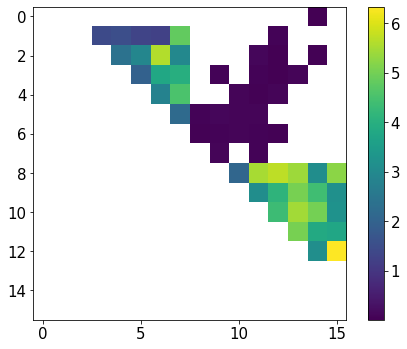

In [ ]:



#bin_means = np.array([np.nanmean(T1R[idx1R//k== i]) for i in range(0, 120)])
bin_means = np.array([np.nanmean(R1R[idx1R//k== i]) for i in range(0, 120)])

Matdist1=np.zeros((Site1.dim,Site1.dim))
Matdist1[np.triu_indices(16,k=1)]=(np.abs(bin_means))
Matdist1[np.tril_indices(16,k=1)]=np.nan

plt.imshow(Matdist1)
plt.colorbar()